# FEI vs Celeb-DF++ Disaggregated Evaluation - All 6 Model Configurations

This notebook extends the disaggregated evaluation introduced in `DualBranch/step3_test.ipynb`
(Section 8) to **all six model configurations** compared in the thesis (Standard
EfficientNet-B0, DeiT-Tiny, EfficientNet-B0 gated, DINOv3 ConvNeXt-S, Dual-Branch Standard,
Dual-Branch Hybrid), both training steps -- 12 checkpoints in total.

The merged test set combines two datasets that are structurally very different (FEI: identity
morphing between two subjects, controlled acquisition; Celeb-DF++: video face-swap/
reenactment/talking-face across 22 methods, "in the wild"), represented in very different
proportions inside the merged test set (29,298 Celeb-DF++ vs 992 FEI samples). A model could
reach a good *merged* accuracy while performing very differently on the two sources. This
notebook reruns Tabella 3.1's metrics (Acc, F1, Prec, Rec, AUC) separately on the FEI-only and
Celeb-DF++-only subsets of the test set, for every one of the 12 checkpoints.

**Requires**: all 12 trained checkpoints already present on Drive under
`deepfake_models_final/` (both training steps for all six configurations must have completed
-- see the six `step1_baseline.ipynb` / `step2_retrain.ipynb` notebook pairs).

**Note:** DINOv3 checkpoints on HuggingFace are gated. Accept the license for both
https://huggingface.co/facebook/dinov3-convnext-small-pretrain-lvd1689m and
https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m and have a read-access token
ready before running the login cell below.

In [8]:
%pip install -q transformers huggingface_hub accelerate timm

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import AutoModel
from huggingface_hub import login
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [9]:
# Environment setup: works both on Colab (Drive-mounted) and on a local VM/JupyterLab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/internship-deepfake-forensic'
    DATASET_DIR = '/content/dataset'
    MODELS_DIR = os.path.join(DRIVE_ROOT, 'deepfake_models_final')

    if not os.path.exists(DATASET_DIR):
        print("Extracting the dataset... (this might take a few minutes)")
        !unzip -q {os.path.join(DRIVE_ROOT, 'deepfake_dataset.zip')} -d {DATASET_DIR}
        print("Extraction completed!")
    else:
        print("Dataset already present and ready to use!")
else:
    DATA_ROOT = '/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework'
    DATASET_DIR = os.path.join(DATA_ROOT, 'Datasets')
    MODELS_DIR = os.path.join(DATA_ROOT, 'deepfake_models_final')
    print(f"Running outside Colab. Using local paths under: {DATA_ROOT}")

print(f"Dataset directory: {DATASET_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already present and ready to use!
Dataset directory: /content/dataset
Models directory:  /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final


In [10]:
# Log in to HuggingFace Hub to access the gated DINOv3 checkpoints
login()

In [11]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dirs, fake_dirs, transform=None):
        self.filepaths, self.labels = [], []
        self.transform = transform
        extensions = ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG')
        for d in real_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([0] * len(paths))
        for d in fake_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([1] * len(paths))

    def __len__(self): return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor([self.labels[idx]], dtype=torch.float32)


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
# --- Model 1: Standard EfficientNet-B0 ---
class StandardEfficientNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.model = models.efficientnet_b0(weights=weights)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# --- Model 2: DeiT-Tiny ---
class DeitTiny(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.model = timm.create_model('deit_tiny_patch16_224', pretrained=pretrained)
        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, num_classes)

    def forward(self, x):
        return self.model(x)


# --- Model 3: EfficientNet-B0 gated / Hybrid ---
class HybridEfficientNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights).features
        in_channels = 1280
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1, bias=False),
            nn.BatchNorm2d(in_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1, bias=False), nn.Sigmoid()
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4), nn.Linear(in_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features * self.attention(features)
        return self.classifier(torch.flatten(self.pool(features), 1))


# --- Model 4: DINOv3 ConvNeXt-S ---
class DINOv3ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=1, model_id="facebook/dinov3-convnext-small-pretrain-lvd1689m"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_id)
        for p in self.backbone.parameters():
            p.requires_grad = False

        hidden_sizes = getattr(self.backbone.config, "hidden_sizes", None)
        hidden_size = hidden_sizes[-1] if hidden_sizes is not None else self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(hidden_size, num_classes)
        )

    def state_dict(self, *args, **kwargs):
        # Only the classification head is trainable/saved: the frozen backbone is skipped,
        # matching what the training notebook actually wrote to the checkpoint.
        return self.classifier.state_dict(*args, **kwargs)

    def load_state_dict(self, state_dict, *args, **kwargs):
        return self.classifier.load_state_dict(state_dict, *args, **kwargs)

    def forward(self, x):
        with torch.no_grad():
            outputs = self.backbone(pixel_values=x)
            features = getattr(outputs, "pooler_output", None)
            if features is None:
                last_hidden = outputs.last_hidden_state
                features = last_hidden.mean(dim=[-2, -1]) if last_hidden.dim() == 4 else last_hidden.mean(dim=1)
        return self.classifier(features)


# --- Models 5 & 6: Dual-Branch Standard / Hybrid ---
class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ffn = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, query_tokens, kv_tokens):
        q = self.norm_q(query_tokens)
        kv = self.norm_kv(kv_tokens)
        attn_out, _ = self.cross_attn(q, kv, kv)
        query_tokens = query_tokens + attn_out
        query_tokens = query_tokens + self.ffn(self.norm_ffn(query_tokens))
        return query_tokens


class DualBranchDinoViTClassifier(nn.Module):
    """CNN + DINOv3 ViT-Small (no self-attention gating) -- Dual-Branch Standard."""
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280

        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)
        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def state_dict(self, *args, **kwargs):
        full = super().state_dict(*args, **kwargs)
        return {k: v for k, v in full.items() if not k.startswith('dino_backbone.')}

    def load_state_dict(self, state_dict, *args, **kwargs):
        return super().load_state_dict(state_dict, *args, strict=False, **kwargs)

    def forward(self, x):
        cnn_features = self.cnn_backbone(x)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)

        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)


class HybridDinoViTClassifier(nn.Module):
    """Hybrid EfficientNet-B0 (self-attention gated) + DINOv3 ViT-Small -- Dual-Branch Hybrid."""
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280
        self.cnn_attention = nn.Sequential(
            nn.Conv2d(cnn_channels, cnn_channels // 8, 1, bias=False),
            nn.BatchNorm2d(cnn_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(cnn_channels // 8, cnn_channels, 1, bias=False), nn.Sigmoid()
        )

        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)
        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def state_dict(self, *args, **kwargs):
        full = super().state_dict(*args, **kwargs)
        return {k: v for k, v in full.items() if not k.startswith('dino_backbone.')}

    def load_state_dict(self, state_dict, *args, **kwargs):
        return super().load_state_dict(state_dict, *args, strict=False, **kwargs)

    def forward(self, x):
        cnn_features = self.cnn_backbone(x)
        cnn_features = cnn_features * self.cnn_attention(cnn_features)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)

        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

# Per-source test loaders (built once, reused for every model)
fei_real_dir, fei_fake_dir = f'{DATASET_DIR}/FEI_MORPHV2_DATASET/test/original/', f'{DATASET_DIR}/FEI_MORPHV2_DATASET/test/fake/'
celeb_real_dir, celeb_fake_dir = f'{DATASET_DIR}/CELEBDFV3_DATASET/test/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/test/fake/'

BATCH = 32
NUM_WORKERS = 4

test_loader_fei = DataLoader(DeepfakeDataset([fei_real_dir], [fei_fake_dir], test_transforms), BATCH, shuffle=False, num_workers=NUM_WORKERS)
test_loader_celeb = DataLoader(DeepfakeDataset([celeb_real_dir], [celeb_fake_dir], test_transforms), BATCH, shuffle=False, num_workers=NUM_WORKERS)

print(f"FEI test samples:   {len(test_loader_fei.dataset)}")
print(f"Celeb test samples: {len(test_loader_celeb.dataset)}")

Device in use: cuda
FEI test samples:   992
Celeb test samples: 29298


In [14]:
print("Loading all 12 checkpoints...")

def load_ckpt(model, path):
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device)

trained_models = {
    "Standard EfficientNet-B0 (Step 1)": load_ckpt(StandardEfficientNet(), os.path.join(MODELS_DIR, 'baseline', 'path', 'std_b0_step1.pth')),
    "Standard EfficientNet-B0 (Step 2)": load_ckpt(StandardEfficientNet(), os.path.join(MODELS_DIR, 'retrain', 'path', 'std_b0_step2.pth')),
    "DeiT-Tiny (Step 1)":                load_ckpt(DeitTiny(), os.path.join(MODELS_DIR, 'baseline', 'path', 'deit_step1.pth')),
    "DeiT-Tiny (Step 2)":                load_ckpt(DeitTiny(), os.path.join(MODELS_DIR, 'retrain', 'path', 'deit_step2.pth')),
    "EfficientNet-B0 gated (Step 1)":    load_ckpt(HybridEfficientNet(), os.path.join(MODELS_DIR, 'baseline', 'path', 'hyb_b0_step1.pth')),
    "EfficientNet-B0 gated (Step 2)":    load_ckpt(HybridEfficientNet(), os.path.join(MODELS_DIR, 'retrain', 'path', 'hyb_b0_step2.pth')),
    "DINOv3 ConvNeXt-S (Step 1)":        load_ckpt(DINOv3ConvNeXtClassifier(), os.path.join(MODELS_DIR, 'baseline_dino', 'path', 'dino_convnext_small_step1.pth')),
    "DINOv3 ConvNeXt-S (Step 2)":        load_ckpt(DINOv3ConvNeXtClassifier(), os.path.join(MODELS_DIR, 'retrain_dino', 'path', 'dino_convnext_small_step2.pth')),
    "Dual-Branch Standard (Step 1)":     load_ckpt(DualBranchDinoViTClassifier(), os.path.join(MODELS_DIR, 'baseline_dualdino', 'path', 'dual_dinovit_step1.pth')),
    "Dual-Branch Standard (Step 2)":     load_ckpt(DualBranchDinoViTClassifier(), os.path.join(MODELS_DIR, 'retrain_dualdino', 'path', 'dual_dinovit_step2.pth')),
    "Dual-Branch Hybrid (Step 1)":       load_ckpt(HybridDinoViTClassifier(), os.path.join(MODELS_DIR, 'baseline_hybriddino', 'path', 'hybrid_dinovit_step1.pth')),
    "Dual-Branch Hybrid (Step 2)":       load_ckpt(HybridDinoViTClassifier(), os.path.join(MODELS_DIR, 'retrain_hybriddino', 'path', 'hybrid_dinovit_step2.pth')),
}

print(f"\nAll {len(trained_models)} checkpoints loaded and ready.")

Loading all 12 checkpoints...


config.json:   0%|          | 0.00/447 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  198MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]


All 12 checkpoints loaded and ready.


In [15]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).view(-1)
            probs = torch.sigmoid(outputs)
            preds = (outputs > 0.0).float()
            all_labels.extend(labels.view(-1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_probs), np.array(all_preds)


def evaluate_by_source(models_dict, loader, device, source_name):
    rows = []
    for name, model in models_dict.items():
        y_true, y_probs, y_preds = get_all_predictions(model, loader, device)
        rows.append({
            "Model": name,
            "Source": source_name,
            "N": len(y_true),
            "Acc": accuracy_score(y_true, y_preds),
            "F1": f1_score(y_true, y_preds),
            "Prec": precision_score(y_true, y_preds),
            "Rec": recall_score(y_true, y_preds),
            "AUC": auc(*roc_curve(y_true, y_probs)[:2]),
        })
    return pd.DataFrame(rows)


print("Evaluating all 12 checkpoints on FEI-only test samples...")
results_fei = evaluate_by_source(trained_models, test_loader_fei, device, "FEI")

print("Evaluating all 12 checkpoints on Celeb-DF++-only test samples...")
results_celeb = evaluate_by_source(trained_models, test_loader_celeb, device, "Celeb-DF++")

results_by_source = pd.concat([results_fei, results_celeb], ignore_index=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
display(results_by_source.sort_values(["Model", "Source"]).reset_index(drop=True))

results_by_source.to_csv("fei_vs_celeb_all_models_results.csv", index=False)
print("\nSaved: fei_vs_celeb_all_models_results.csv")

Evaluating all 12 checkpoints on FEI-only test samples...
Evaluating all 12 checkpoints on Celeb-DF++-only test samples...


,Model,Source,N,Acc,F1,Prec,Rec,AUC
0,DINOv3 ConvNeXt-S (Step 1),Celeb-DF++,29298,0.7182,0.8340,0.9897,0.7206,0.7055
1,DINOv3 ConvNeXt-S (Step 1),FEI,992,0.9698,0.9839,0.9882,0.9797,0.9804
2,DINOv3 ConvNeXt-S (Step 2),Celeb-DF++,29298,0.6524,0.7868,0.9900,0.6528,0.7044
3,DINOv3 ConvNeXt-S (Step 2),FEI,992,0.9647,0.9811,0.9934,0.9691,0.9749
4,DeiT-Tiny (Step 1),Celeb-DF++,29298,0.8062,0.8918,0.9875,0.8131,0.6885
5,DeiT-Tiny (Step 1),FEI,992,0.8851,0.9376,0.9640,0.9126,0.7380
6,DeiT-Tiny (Step 2),Celeb-DF++,29298,0.8866,0.9395,0.9881,0.8954,0.7350
7,DeiT-Tiny (Step 2),FEI,992,0.6522,0.7770,0.9869,0.6407,0.8504
8,Dual-Branch Hybrid (Step 1),Celeb-DF++,29298,0.8452,0.9148,0.9961,0.8458,0.9190
9,Dual-Branch Hybrid (Step 1),FEI,992,0.9587,0.9777,1.0000,0.9563,0.9965



Saved: fei_vs_celeb_all_models_results.csv



Acc by source (positive gap = FEI recognized better than Celeb-DF++):


Source,Celeb-DF++,FEI,Gap (FEI - Celeb-DF++)
Model,,,
Standard EfficientNet-B0 (Step 1),0.8075,0.9526,0.1451
Standard EfficientNet-B0 (Step 2),0.7925,0.9708,0.1782
DeiT-Tiny (Step 1),0.8062,0.8851,0.0788
DeiT-Tiny (Step 2),0.8866,0.6522,-0.2344
EfficientNet-B0 gated (Step 1),0.8681,0.9274,0.0593
EfficientNet-B0 gated (Step 2),0.8567,0.9567,0.0999
DINOv3 ConvNeXt-S (Step 1),0.7182,0.9698,0.2516
DINOv3 ConvNeXt-S (Step 2),0.6524,0.9647,0.3123
Dual-Branch Standard (Step 1),0.8248,0.9708,0.1460



F1 by source (positive gap = FEI recognized better than Celeb-DF++):


Source,Celeb-DF++,FEI,Gap (FEI - Celeb-DF++)
Model,,,
Standard EfficientNet-B0 (Step 1),0.8917,0.9744,0.0827
Standard EfficientNet-B0 (Step 2),0.8825,0.9843,0.1019
DeiT-Tiny (Step 1),0.8918,0.9376,0.0458
DeiT-Tiny (Step 2),0.9395,0.7770,-0.1625
EfficientNet-B0 gated (Step 1),0.9283,0.9601,0.0318
EfficientNet-B0 gated (Step 2),0.9218,0.9767,0.0549
DINOv3 ConvNeXt-S (Step 1),0.8340,0.9839,0.1500
DINOv3 ConvNeXt-S (Step 2),0.7868,0.9811,0.1943
Dual-Branch Standard (Step 1),0.9024,0.9843,0.0819



Prec by source (positive gap = FEI recognized better than Celeb-DF++):


Source,Celeb-DF++,FEI,Gap (FEI - Celeb-DF++)
Model,,,
Standard EfficientNet-B0 (Step 1),0.9966,0.9967,0.0000
Standard EfficientNet-B0 (Step 2),0.9951,0.9989,0.0038
DeiT-Tiny (Step 1),0.9875,0.9640,-0.0235
DeiT-Tiny (Step 2),0.9881,0.9869,-0.0012
EfficientNet-B0 gated (Step 1),0.9970,1.0000,0.0030
EfficientNet-B0 gated (Step 2),0.9931,0.9923,-0.0008
DINOv3 ConvNeXt-S (Step 1),0.9897,0.9882,-0.0016
DINOv3 ConvNeXt-S (Step 2),0.9900,0.9934,0.0035
Dual-Branch Standard (Step 1),0.9966,1.0000,0.0034



Rec by source (positive gap = FEI recognized better than Celeb-DF++):


Source,Celeb-DF++,FEI,Gap (FEI - Celeb-DF++)
Model,,,
Standard EfficientNet-B0 (Step 1),0.8068,0.9531,0.1463
Standard EfficientNet-B0 (Step 2),0.7927,0.9701,0.1774
DeiT-Tiny (Step 1),0.8131,0.9126,0.0995
DeiT-Tiny (Step 2),0.8954,0.6407,-0.2547
EfficientNet-B0 gated (Step 1),0.8684,0.9232,0.0549
EfficientNet-B0 gated (Step 2),0.8601,0.9616,0.1015
DINOv3 ConvNeXt-S (Step 1),0.7206,0.9797,0.2592
DINOv3 ConvNeXt-S (Step 2),0.6528,0.9691,0.3163
Dual-Branch Standard (Step 1),0.8244,0.9691,0.1447



AUC by source (positive gap = FEI recognized better than Celeb-DF++):


Source,Celeb-DF++,FEI,Gap (FEI - Celeb-DF++)
Model,,,
Standard EfficientNet-B0 (Step 1),0.9078,0.9891,0.0814
Standard EfficientNet-B0 (Step 2),0.8703,0.9972,0.1268
DeiT-Tiny (Step 1),0.6885,0.7380,0.0495
DeiT-Tiny (Step 2),0.7350,0.8504,0.1154
EfficientNet-B0 gated (Step 1),0.9354,0.9890,0.0537
EfficientNet-B0 gated (Step 2),0.8733,0.9793,0.1059
DINOv3 ConvNeXt-S (Step 1),0.7055,0.9804,0.2749
DINOv3 ConvNeXt-S (Step 2),0.7044,0.9749,0.2705
Dual-Branch Standard (Step 1),0.9161,0.9974,0.0813


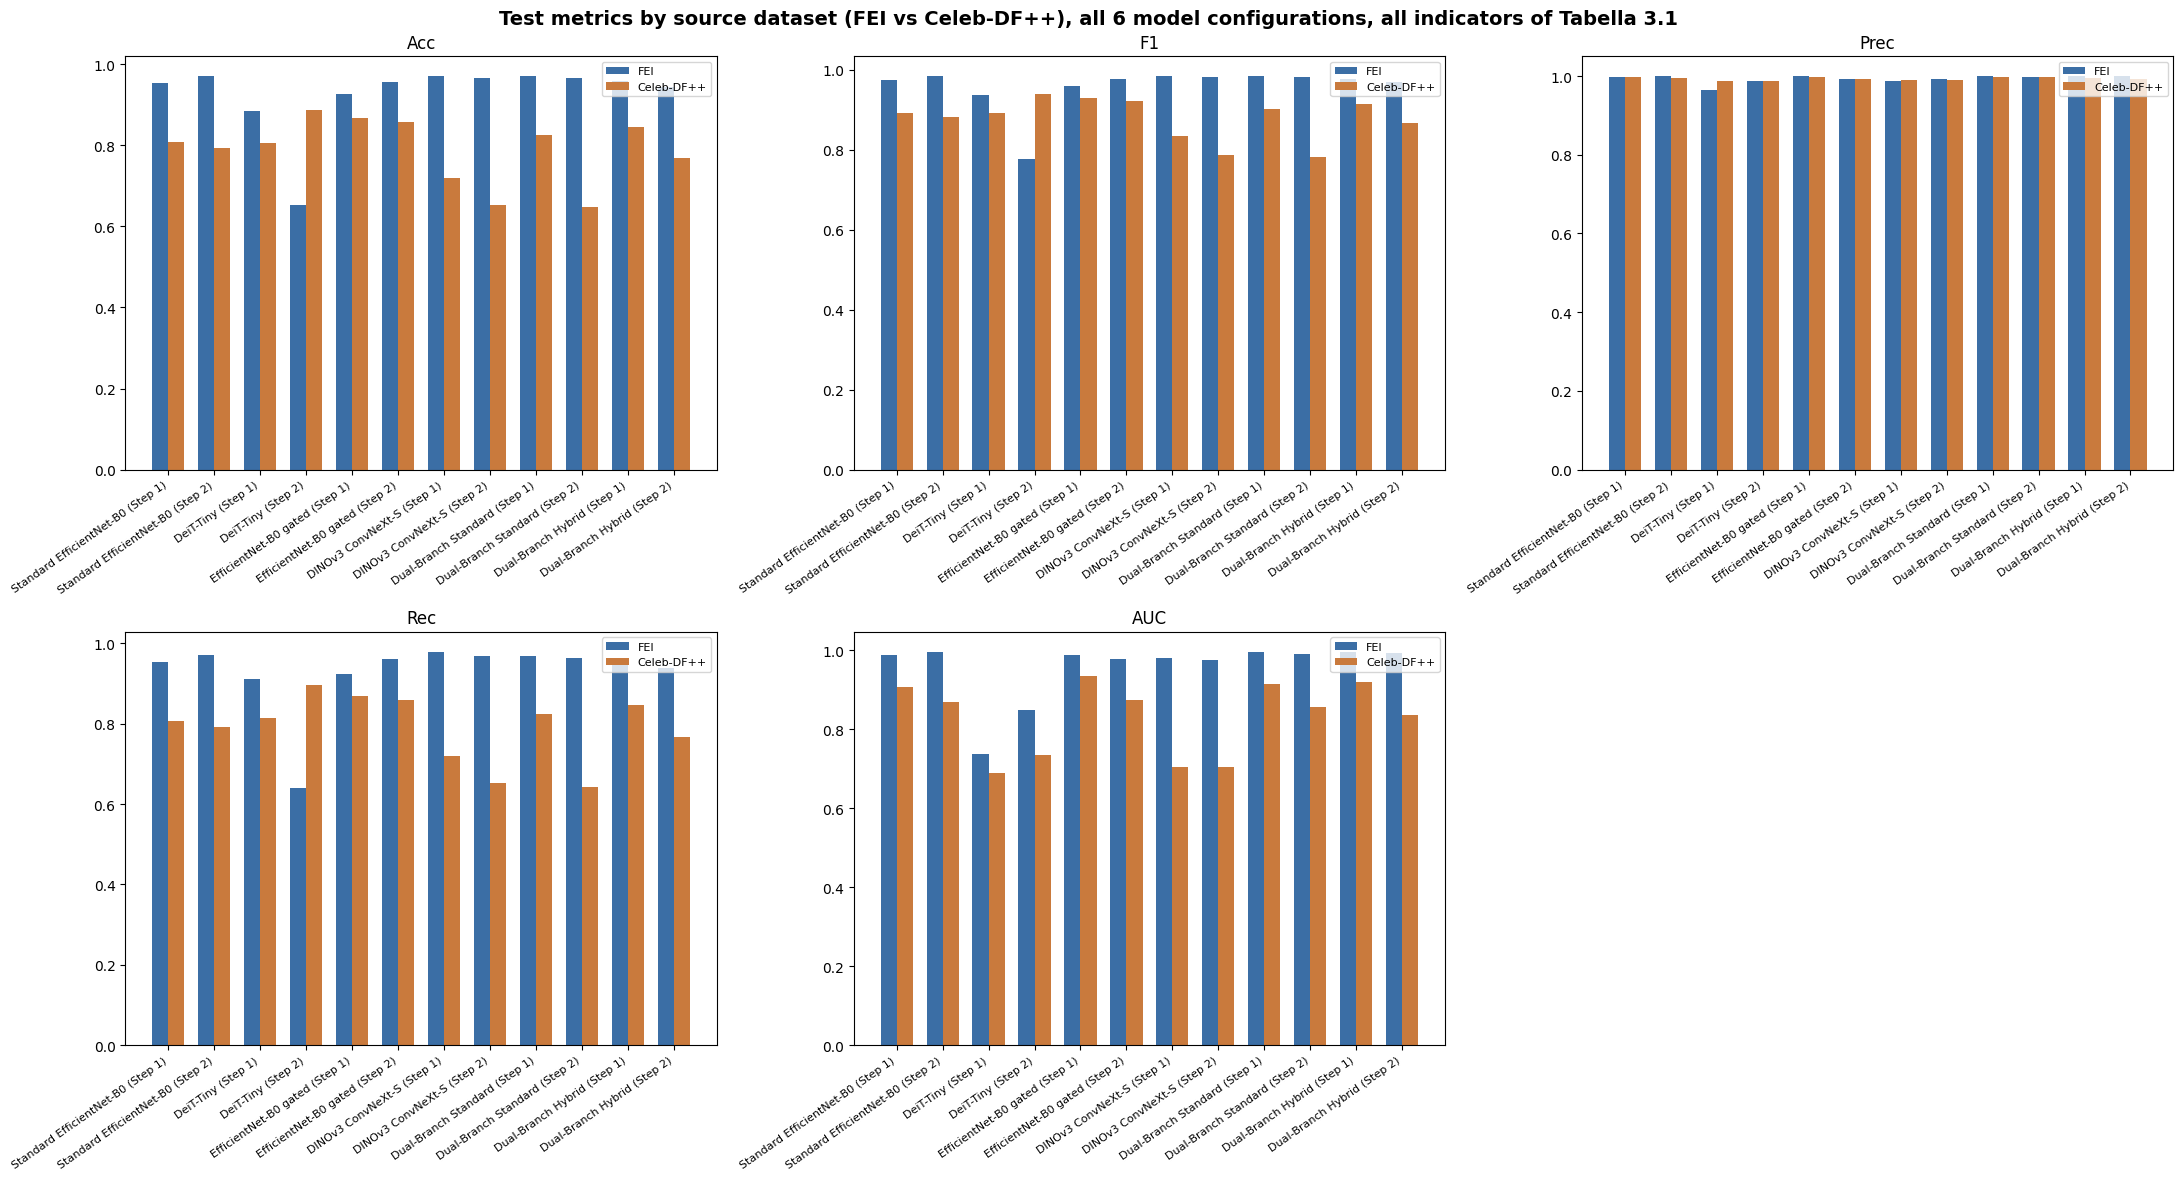


Saved: fei_vs_celeb_all_models_all_metrics.png


In [16]:
metrics = ["Acc", "F1", "Prec", "Rec", "AUC"]
model_order = list(trained_models.keys())

for metric in metrics:
    piv = results_by_source.pivot(index="Model", columns="Source", values=metric).loc[model_order]
    piv["Gap (FEI - Celeb-DF++)"] = piv["FEI"] - piv["Celeb-DF++"]
    print(f"\n{metric} by source (positive gap = FEI recognized better than Celeb-DF++):")
    display(piv.round(4))

# Bar chart for the thesis figure: one panel per metric, FEI vs Celeb-DF++ bars for all 12 models
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
x = np.arange(len(model_order))
width = 0.35

for ax, metric in zip(axes, metrics):
    fei_vals = results_fei.set_index("Model").loc[model_order, metric]
    celeb_vals = results_celeb.set_index("Model").loc[model_order, metric]

    ax.bar(x - width / 2, fei_vals, width, label="FEI", color="#3b6ea5")
    ax.bar(x + width / 2, celeb_vals, width, label="Celeb-DF++", color="#c97a3d")
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right", fontsize=8)
    ax.set_title(metric)
    ax.legend(fontsize=8)

axes[-1].axis("off")  # 6th panel unused (5 metrics, 2x3 grid)
fig.suptitle("Test metrics by source dataset (FEI vs Celeb-DF++), all 6 model configurations, all indicators of Tabella 3.1", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fei_vs_celeb_all_models_all_metrics.png", dpi=200)
plt.show()

print("\nSaved: fei_vs_celeb_all_models_all_metrics.png")